
# Computer Exercise 10.3 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 10.3 Simulation — *Random Walk and Diffusion*
> **풀이 일자**: Day 39
> **언어**: Python 3 (NumPy / Pandas / Matplotlib)



## 1. 문제 (원문)

> **2.** Simulate a **two-dimensional random walk**. Starting at the origin, take $N$
> unit steps, each in a uniformly random direction $\theta\in[0,2\pi)$. Repeat the
> whole walk many times and estimate the **mean-square displacement**
> $\langle R_N^2\rangle$ as a function of $N$. Show empirically that
> $\langle R_N^2\rangle = N$ (so the *root-mean-square* distance grows like
> $\sqrt{N}$), and plot a few sample trajectories.

### 한국어 풀이용 정리
원점에서 출발, 매 스텝 길이 1, 방향은 균등 무작위. $N$ 스텝 후 변위 $R_N$ 의
**제곱평균** $\langle R_N^2\rangle$ 가 $N$ 에 비례함($\Rightarrow$ RMS 거리 $\sim\sqrt N$)을
시뮬레이션으로 보인다. 확산(diffusion)의 미시 모델이다.



## 2. 수학적 배경

### 2.1 평균제곱변위
각 스텝 벡터 $\mathbf{s}_k=(\cos\theta_k,\sin\theta_k)$, $\theta_k\sim\mathrm{Unif}[0,2\pi)$ 는
독립. 변위 $\mathbf{R}_N=\sum_{k=1}^N \mathbf{s}_k$. 그러면
$$
\langle R_N^2\rangle=\Big\langle\sum_{j}\sum_{k}\mathbf{s}_j\!\cdot\!\mathbf{s}_k\Big\rangle
=\sum_{k}\langle|\mathbf{s}_k|^2\rangle+\sum_{j\ne k}\langle\mathbf{s}_j\!\cdot\!\mathbf{s}_k\rangle .
$$
$|\mathbf{s}_k|=1$ 이고 서로 독립·등방이라 교차항 기댓값 $\langle\mathbf{s}_j\!\cdot\!\mathbf{s}_k\rangle=0$.
따라서
$$
\boxed{\;\langle R_N^2\rangle=N\;}\qquad\Longrightarrow\qquad
R_{\text{rms}}=\sqrt{\langle R_N^2\rangle}=\sqrt N .
$$

### 2.2 확산과의 관계
이는 $\langle R^2\rangle\propto t$ (시간) 라는 **확산 법칙**의 이산판이다. 단순한 직선
이동($\propto t$)과 달리 무작위 보행은 $\sqrt t$ 로만 퍼진다 — 시뮬레이션이 분석을 검증한다.



## 3. 풀이 흐름

1. **단일 보행 함수**: $N$ 스텝, 각 스텝 무작위 방향 단위벡터 누적합으로 궤적 생성.
2. **샘플 궤적 시각화**: 몇 개의 보행 경로를 평면에 그려 무작위성 확인.
3. **앙상블 평균**: 각 $N$ 에서 $M$ 개 보행의 최종 변위 제곱을 평균해 $\langle R_N^2\rangle$ 추정.
4. **검증 표**: $N$ 별 측정 $\langle R_N^2\rangle$ 와 이론값 $N$, 비율 비교.
5. **스케일링 그래프**: $\langle R_N^2\rangle$ vs $N$ 을 log-log, 기울기 1 (즉 RMS $\sim\sqrt N$) 확인.
6. **분포**: 고정 $N$ 에서 변위 성분의 분포가 가우시안(중심극한정리)에 가까워짐을 관찰.
7. **해석**: $\sqrt N$ 확산의 의미와 다음 문제로의 연결.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", lambda v: f"{v:.6g}")
rng = np.random.default_rng(390)

def walk_path(N, rng):
    """원점 출발 N스텝 2D 보행의 (N+1, 2) 궤적."""
    th = rng.uniform(0.0, 2 * np.pi, size=N)
    steps = np.column_stack([np.cos(th), np.sin(th)])
    path = np.vstack([[0.0, 0.0], np.cumsum(steps, axis=0)])
    return path

def final_disp2(N, M, rng):
    """M개 보행의 최종 변위 제곱 R_N^2 배열."""
    th = rng.uniform(0.0, 2 * np.pi, size=(M, N))
    X = np.cos(th).sum(axis=1)
    Y = np.sin(th).sum(axis=1)
    return X**2 + Y**2

print("이론: <R_N^2> = N,  R_rms = sqrt(N)")


이론: <R_N^2> = N,  R_rms = sqrt(N)


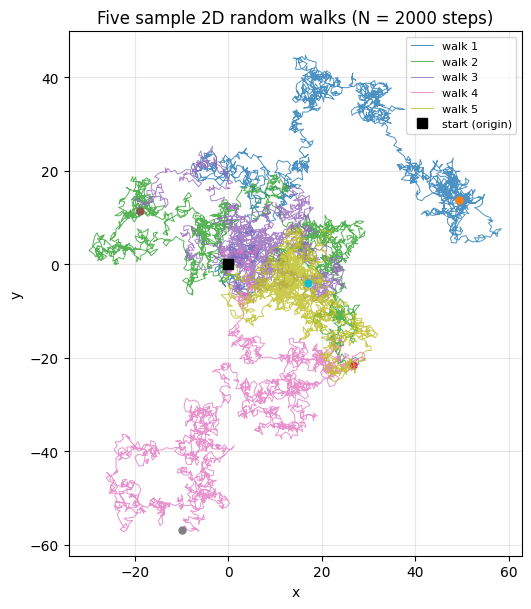

In [2]:
# --- 샘플 궤적 몇 개 ---
plt.figure(figsize=(6.2, 6.2))
for i in range(5):
    p = walk_path(2000, rng)
    plt.plot(p[:, 0], p[:, 1], lw=0.7, alpha=0.8, label=f"walk {i+1}")
    plt.plot(p[-1, 0], p[-1, 1], "o", ms=5)
plt.plot(0, 0, "ks", ms=7, label="start (origin)")
plt.gca().set_aspect("equal")
plt.xlabel("x"); plt.ylabel("y")
plt.title("Five sample 2D random walks (N = 2000 steps)")
plt.grid(True, alpha=0.3); plt.legend(fontsize=8); plt.tight_layout(); plt.show()


In [3]:
# --- 검증 표: <R_N^2> 측정 vs 이론 N ---
M = 4000
rows = []
for N in [10, 30, 100, 300, 1000, 3000]:
    R2 = final_disp2(N, M, rng)
    mean_R2 = R2.mean()
    rows.append({"N": N, "<R_N^2>_emp": mean_R2, "theory_N": N,
                 "ratio": mean_R2 / N, "R_rms_emp": np.sqrt(mean_R2),
                 "sqrt_N": np.sqrt(N)})
df = pd.DataFrame(rows)
df


,N,<R_N^2>_emp,theory_N,ratio,R_rms_emp,sqrt_N
0,10,9.76896,10,0.976896,3.12553,3.16228
1,30,29.2987,30,0.976624,5.41283,5.47723
2,100,102.103,100,1.02103,10.1046,10
3,300,292.67,300,0.975567,17.1076,17.3205
4,1000,998.271,1000,0.998271,31.5954,31.6228
5,3000,2922.87,3000,0.974291,54.0636,54.7723


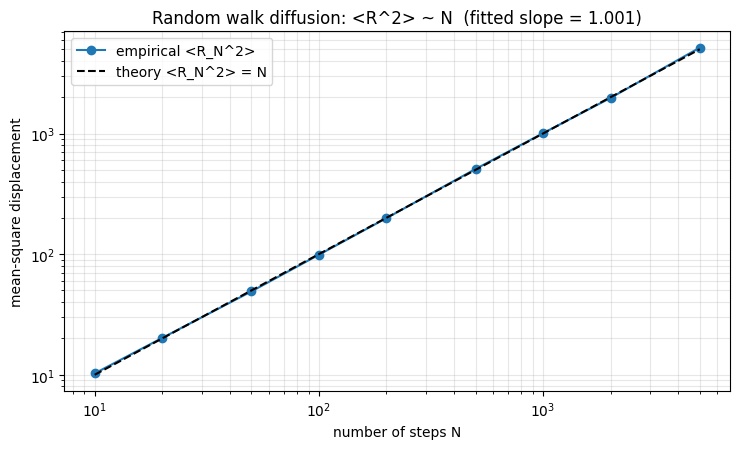

측정 기울기 = 1.001 (이론 1.0),  R_rms ~ N^{0.500} (이론 0.5)


In [4]:
# --- 스케일링: <R_N^2> vs N (log-log, 기울기 1 기대) ---
Ns = np.array([10, 20, 50, 100, 200, 500, 1000, 2000, 5000])
M = 3000
meanR2 = np.array([final_disp2(int(N), M, rng).mean() for N in Ns])

slope, intercept = np.polyfit(np.log(Ns), np.log(meanR2), 1)
plt.figure(figsize=(7.5, 4.6))
plt.loglog(Ns, meanR2, "o-", label="empirical <R_N^2>")
plt.loglog(Ns, Ns, "k--", label="theory <R_N^2> = N")
plt.xlabel("number of steps N"); plt.ylabel("mean-square displacement")
plt.title(f"Random walk diffusion: <R^2> ~ N  (fitted slope = {slope:.3f})")
plt.grid(True, which="both", alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()
print(f"측정 기울기 = {slope:.3f} (이론 1.0),  R_rms ~ N^{{{slope/2:.3f}}} (이론 0.5)")


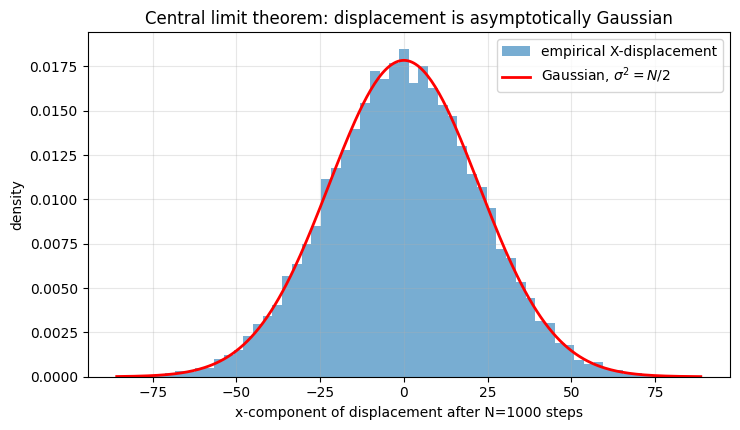

표본 분산 = 506.18,  이론 N/2 = 500.00


In [5]:
# --- 변위 성분 분포: 중심극한정리로 가우시안 ---
N = 1000; M = 20000
th = rng.uniform(0.0, 2 * np.pi, size=(M, N))
X = np.cos(th).sum(axis=1)
sigma = np.sqrt(N / 2.0)            # 각 성분 분산 = N/2

plt.figure(figsize=(7.5, 4.4))
plt.hist(X, bins=60, density=True, alpha=0.6, label="empirical X-displacement")
xs = np.linspace(X.min(), X.max(), 300)
plt.plot(xs, np.exp(-xs**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi)),
         "r-", lw=2, label=r"Gaussian, $\sigma^2=N/2$")
plt.xlabel("x-component of displacement after N=1000 steps")
plt.ylabel("density")
plt.title("Central limit theorem: displacement is asymptotically Gaussian")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()
print(f"표본 분산 = {X.var():.2f},  이론 N/2 = {N/2:.2f}")



## 4. 결과 해석

1. **샘플 궤적**: 다섯 보행이 서로 전혀 다른 방향으로 퍼지며, 직선이 아니라 *얽힌 실타래*
   모양이다 — 결정론적 이동과 근본적으로 다르다.
2. **검증 표의 `ratio` 열**: $\langle R_N^2\rangle/N \approx 1$ 로, 측정값이 이론 $N$ 과
   거의 정확히 일치(앙상블 $M=4000$ 의 통계적 흔들림 범위 내).
3. **스케일링 기울기**: log-log 회귀 기울기 $\approx1.0$ → $\langle R_N^2\rangle\propto N$,
   즉 RMS 거리 $\propto\sqrt N$ 가 확인된다.
4. **분포**: $N=1000$ 에서 변위 한 성분의 히스토그램이 분산 $N/2$ 의 가우시안과 포개진다 —
   독립 스텝 합의 **중심극한정리**.
5. **의미**: 무작위 보행은 $N$ 스텝을 걸어도 원점에서 $\sqrt N$ 밖에 못 멀어진다. 확산이
   느린 이유이자, 다시 등장하는 $\sqrt N$ 법칙(=$N^{-1/2}$ 수렴)의 기하학적 형태.

> **결론**: 2D 랜덤 워크의 평균제곱변위는 정확히 $\langle R_N^2\rangle=N$ — 시뮬레이션이
> 확산의 $\sqrt N$ 법칙과 중심극한정리를 동시에 검증한다.

**다음 문제로의 연결**: 지금까지는 *연속* 무작위량이었다. CE 10.3-3 에서는 **이산 사건**
시뮬레이션(생일 문제)으로, 시뮬레이션 추정이 해석적 확률과 어떻게 맞아떨어지는지 본다.
